In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv("diabetes.csv")

In [4]:
print(df.head())
print(df.info())
print(df.describe)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null  

In [5]:
cols_with_zero=['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[cols_with_zero]=df[cols_with_zero].replace(0,np.nan)

print("Missing Values after replacing Zeros")
print(df.isnull().sum())

df[cols_with_zero]=df[cols_with_zero].fillna(df[cols_with_zero].median())
print(df.isnull().sum())

Missing Values after replacing Zeros


Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


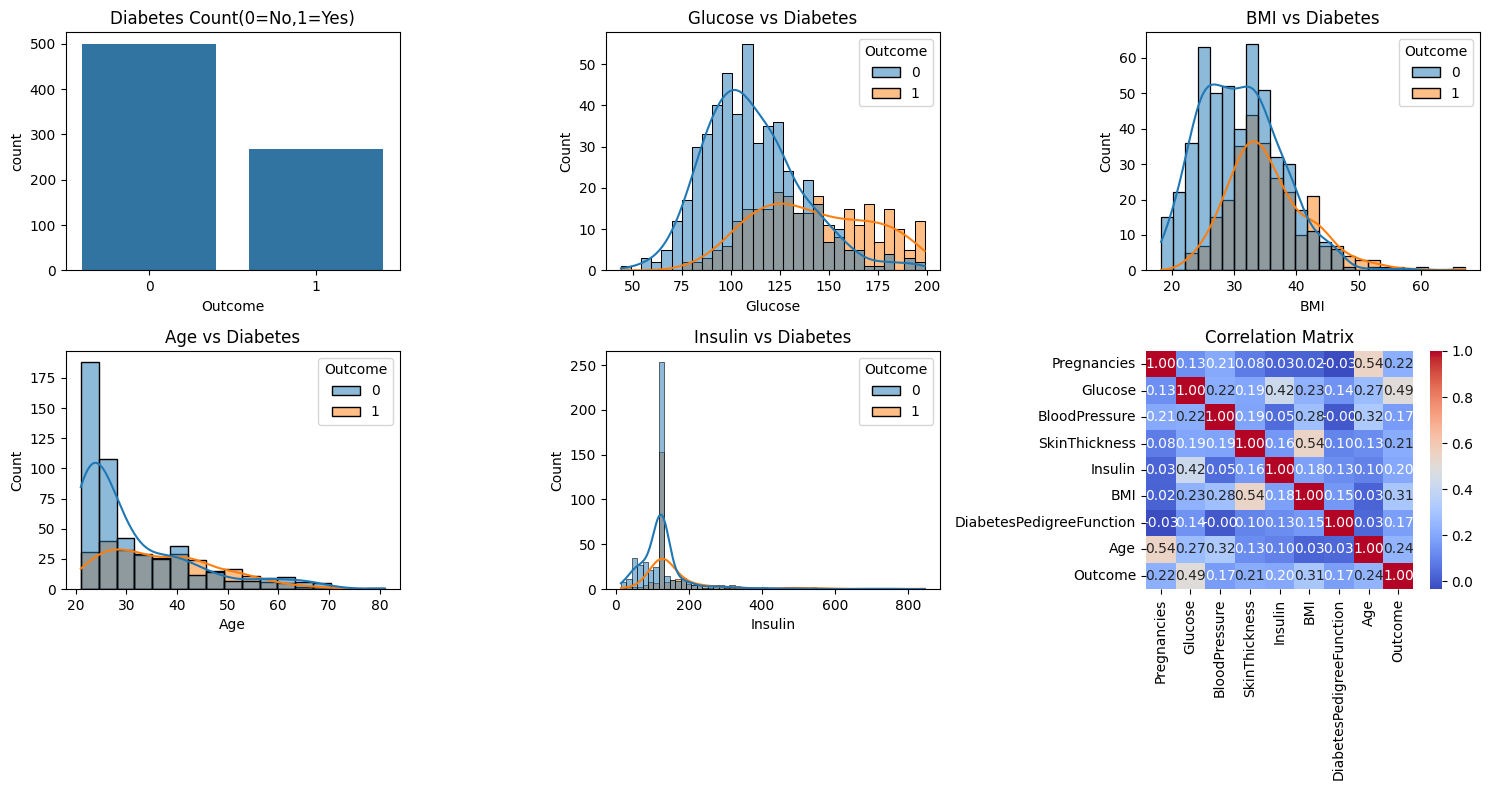

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig,axes = plt.subplots(2,3, figsize=(15,8))

sns.countplot(x='Outcome',data=df,ax=axes[0,0])
axes[0,0].set_title('Diabetes Count(0=No,1=Yes)')

sns.histplot(data=df,x='Glucose',hue='Outcome',bins=30,kde=True,ax=axes[0,1])
axes[0,1].set_title('Glucose vs Diabetes')

sns.histplot(data=df,x='BMI',hue='Outcome',kde=True,ax=axes[0,2])
axes[0,2].set_title('BMI vs Diabetes')

sns.histplot(data=df,x='Age',hue='Outcome',kde=True,ax=axes[1,0])
axes[1,0].set_title('Age vs Diabetes')

sns.histplot(data=df,x='Insulin',hue='Outcome',kde=True,ax=axes[1,1])
axes[1,1].set_title('Insulin vs Diabetes')

sns.heatmap(df.corr(), annot=True, fmt='.2f',cmap='coolwarm',ax=axes[1,2])
axes[1,2].set_title('Correlation Matrix')

plt.tight_layout()
plt.savefig('eda.png')
plt.show()



In [10]:
x=df.drop('Outcome',axis=1)
y=df['Outcome']

In [12]:
from sklearn.model_selection import train_test_split
x_train, x_test,y_train, y_test= train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [14]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()

x_train= scaler.fit_transform(x_train)
x_test-scaler.transform(x_test)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
668,5.318144,98.791466,59.177033,32.489798,189.438065,33.762135,0.546372,42.121909
324,2.526397,112.326051,74.770844,31.608774,125.175620,35.216820,1.102231,22.035940
624,2.526397,108.459026,64.680731,28.965702,125.175620,31.023904,1.082520,22.035940
690,6.714017,107.492270,79.357260,28.965702,125.175620,25.718582,-0.293329,33.904922
473,6.016081,135.528196,88.530090,28.965702,125.175620,30.253777,0.980021,48.512899
...,...,...,...,...,...,...,...,...
355,7.411954,163.564121,86.695524,28.965702,125.175620,30.681626,0.798677,47.599901
534,1.828460,78.489589,57.342466,29.846726,56.958562,33.163147,-1.071925,24.774936
344,6.714017,95.891198,72.018995,28.965702,125.175620,36.158087,0.437960,54.903889
296,2.526397,145.195756,70.184429,36.894918,357.509078,28.627953,0.729688,29.339929


In [17]:
from sklearn.neighbors import KNeighborsClassifier

knn= KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [22]:
y_pred= knn.predict(x_test)

c:\MLprojects\Diabetes(KNN)\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


In [23]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
print("Accuracy:", accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.35064935064935066
[[ 2 97]
 [ 3 52]]
              precision    recall  f1-score   support

           0       0.40      0.02      0.04        99
           1       0.35      0.95      0.51        55

    accuracy                           0.35       154
   macro avg       0.37      0.48      0.27       154
weighted avg       0.38      0.35      0.21       154



c:\MLprojects\Diabetes(KNN)\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
c:\MLprojects\Diabetes(KNN)\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
c:\MLprojects\Diabetes(KNN)\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
c:\MLprojects\Diabetes(KNN)\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
c:\MLprojects\Diabetes(KNN)\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
c:\MLprojects\Diabetes(KN

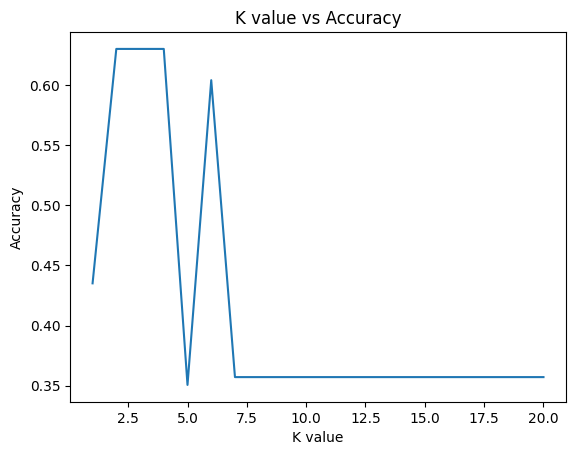

In [24]:
accuracies=[]

for k in range(1,21):
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train,y_train)
    y_pred=knn.predict(x_test)
    accuracies.append(accuracy_score(y_test,y_pred))

plt.plot(range(1,21),accuracies)
plt.xlabel('K value')
plt.ylabel('Accuracy')
plt.title('K value vs Accuracy')
plt.show()